# Phase 2-4: Exploratory Data Analysis

## Setup & Data Loading
Import core libraries and load the **cleaned** dataset produced in Phase 1
(`data/processed/retail_sales_cleaned.csv`). All analysis below assumes the
data has already passed cleaning and validation.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.axes
import seaborn as sns 

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../data/processed/retail_sales_cleaned.csv", parse_dates = ['order_date'])

# Retail Sales Analysis — Phase 2: Exploratory Analysis

This notebook explores the **cleaned retail sales dataset** produced in Phase 1. Using pandas aggregations and grouping, we surface patterns in revenue, regional performance, payment behavior, discount sensitivity, temporal trends, and customer demographics.

All analysis runs on `retail_sales_cleaned.csv`, the analysis-ready output of the Phase 1 pipeline (deduplicated, imputed, and feature-engineered). Note that `customer_age`, `customer_rating`, and `payment_method` contain imputed values where the original data was missing; aggregate results therefore include these estimated values alongside observed ones.

--- 

## 1. Top 5 Best-Selling Products by Total Revenue

In [3]:
display(df.groupby('product', as_index = False).agg(
    total_revenue = ('total_price', 'sum')).sort_values('total_revenue',ascending = False).reset_index(
        drop = True).iloc[:5])

,product,total_revenue
0,Laptop,498131.86
1,Smartphone,325882.74
2,Tablet,186874.04
3,Bicycle,140500.62
4,Smartwatch,106473.64


## 2. Regional Revenue: Highest and Lowest

In [4]:
regional_revenue = df.groupby('region')['total_price'].sum()
print(f'Highest Revenue Generator Region: {regional_revenue.idxmax()}')
print(f'Lowest Revenue Generator Region: {regional_revenue.idxmin()}')

Highest Revenue Generator Region: West
Lowest Revenue Generator Region: Central


## 3. Average Order Value per Payment Method

In [5]:
display(df.groupby('payment_method', as_index = False).agg(
    avg_order_value = ('total_price', 'mean')).sort_values('avg_order_value').reset_index(drop = True))

,payment_method,avg_order_value
0,PayPal,328.903614
1,Cash,358.103222
2,Credit Card,371.287609
3,Debit Card,376.942995
4,Gift Card,427.418214


## 4. Relationship Between Discount and Customer Rating

In [6]:
display(df.groupby('discount_pct', as_index = False).agg(
    avg_customer_rating = ('customer_rating', 'mean')).sort_values('discount_pct').reset_index(drop = True))

,discount_pct,avg_customer_rating
0,0,3.669246
1,5,3.746853
2,10,3.825899
3,15,3.836761
4,20,4.018817


### Summary: Discount Percentage vs. Customer Rating

The data shows a clear **positive trend**: as discounts go up, customer ratings also go up across every single level:

* **0% Discount:** 3.67 Stars
* **5% Discount:** 3.75 Stars
* **10% Discount:** 3.83 Stars
* **15% Discount:** 3.84 Stars
* **20% Discount:** 4.02 Stars

#### Key Takeaway
Customers give higher ratings when they get bigger discounts. The biggest jump happens at the **20% discount level**, where the average rating climbs above 4.0 stars—about **0.35 stars higher** than items bought at full price.

---

## 5. Peak Month and Busiest Weekday

In [7]:
peak_month = df.groupby('order_month')['total_price'].sum().idxmax()
print(f'The month with the highest total sales: {peak_month}')

peak_day = df.groupby('order_weekday')['order_id'].count().idxmax()
print(f'The day with the highest total orders: {peak_day}')

The month with the highest total sales: September
The day with the highest total orders: Thursday


## 6. Spending by Age Group

In [8]:
df['age_group'] = pd.cut(df['customer_age'], bins = [17,25,35,45,60,75], 
                         labels = ["18-25", "26-35", "36-45", "46-60", "60+"])

peak_group_age = df.groupby('age_group', observed = True)['total_price'].mean().idxmax()

print(f'The group age which spends most on average: {peak_group_age}')

The group age which spends most on average: 18-25


# Retail Sales Analysis - Phase 3: Visualization Dashboard

With the data cleaned (Phase 1) and the core business questions answered (Phase 2),
we now move into **visual storytelling**. The goal of this phase is to translate our
tabular findings into charts that surface patterns at a glance — trends, distributions,
proportions, and outliers that are hard to read from raw numbers.

**Tasks in this phase:**

1. **Bar chart** — total revenue by category.
2. **Line chart** — total monthly revenue over time (2023–2024 trend).
3. **Pie chart** — share of orders by payment method.
4. **Horizontal bar chart** — top 10 products by total quantity sold.
5. **Histogram** — distribution of `customer_age`.
6. **Boxplot** — `total_price` by region, highlighting outliers.
7. **Scatter / strip plot** — `discount_pct` vs `customer_rating` (with jitter,
   since both axes hold repeating discrete values).
8. **Grouped bar chart** — revenue by region, broken down by category.

**Bonus challenge:** rather than rendering these as eight standalone figures, we
combine them into a **single consolidated dashboard** using `plt.subplots()` on a
4×2 grid — a layout that reads like an executive summary panel.

All charts are built on the cleaned dataset (`retail_sales_cleaned.csv`)

--- 

### Helper: `style_axis`

A lightweight utility to apply consistent axis labels, titles, and font styling across all subplots. Keeps our plotting functions DRY and ensures visual coherence in the final dashboard.

In [9]:
def style_axis(
    ax: matplotlib.axes.Axes,
    x_label: str | None,
    y_label: str | None,
    title: str,
    label_fontsize: int = 12,
    title_fontsize: int = 14,
    title_fontweight: str = 'bold',
) -> None:
    """
    Apply consistent axis labels and title to a subplot.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The subplot to style (e.g., ax[3][1]).
    x_label : str or None
        Label for the x-axis. If None, no label is set.
    y_label : str or None
        Label for the y-axis. If None, no label is set.
    title : str
        Title for the subplot.
    label_fontsize : int, default=12
        Font size for both x and y axis labels.
    title_fontsize : int, default=14
        Font size for the title.
    title_fontweight : str, default='bold'
        Font weight for the title.
    """
    if x_label is not None:
        ax.set_xlabel(x_label, fontsize = label_fontsize)
    if y_label is not None:
        ax.set_ylabel(y_label, fontsize = label_fontsize)
    ax.set_title(title, fontsize = title_fontsize, fontweight = title_fontweight)

### 1. Total Revenue by Category

Bar chart showing gross revenue distribution across product categories.

In [10]:
def plot_revenue_by_category(
    df: pd.DataFrame,
    ax: matplotlib.axes.Axes,
) -> None:
    """
    Bar chart showing total revenue for each product category.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned retail sales dataframe with 'category' and 'total_price' columns.
    ax : matplotlib.axes.Axes
        The subplot axis on which to draw the chart.
    """
    revenue_by_cat = df.groupby('category', as_index = False).agg(total_revenue = ('total_price', 'sum'))
    sns.barplot(data = revenue_by_cat, x = 'category',y = 'total_revenue', ax = ax, hue = 'category',
        legend = False, palette = 'Blues_r')
    style_axis(ax, 'Product Category', 'Total Revenue ($)', 'Revenue by Category')
    ax.ticklabel_format(style = 'plain', axis = 'y')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))

### 2. Monthly Revenue Trend (2023–2024)

Line chart tracking total revenue over time to identify seasonality and growth patterns.


In [11]:
def plot_monthly_revenue_trend(
    df: pd.DataFrame,
    ax: matplotlib.axes.Axes,
) -> None:
    """
    Line chart showing monthly revenue trend from 2023 to 2024.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned retail sales dataframe with 'order_date' and 'total_price' columns.
    ax : matplotlib.axes.Axes
        The subplot axis on which to draw the chart.
    """
    df['order_Y-M'] = df['order_date'].dt.strftime('%Y-%m')
    monthly_revenue = df.groupby('order_Y-M', as_index = False, observed = True).agg(total_revenue = ('total_price', 'sum'))
    sns.lineplot(data = monthly_revenue, x = 'order_Y-M', y = 'total_revenue', ax = ax,
                marker = "o", color = "#1f77b4", linewidth = 2.5 )
    style_axis(ax, 'Timeline', 'Total Revenue ($)', 'Monthly Revenue Trend (2023-2024)')
    ax.tick_params(axis = 'x', rotation = 90)

### 3. Payment Method Distribution

Pie chart showing the proportion of orders by payment method.

In [12]:
def plot_payment_method_share(
    df: pd.DataFrame,
    ax: matplotlib.axes.Axes,
) -> None:
    """
    Pie chart showing the share of orders by payment method.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned retail sales dataframe with 'payment_method' column.
    ax : matplotlib.axes.Axes
        The subplot axis on which to draw the chart.
    """
    pm_order_share = df['payment_method'].value_counts()
    ax.pie(pm_order_share.values, labels = pm_order_share.index, autopct = "%1.1f%%", 
                startangle = 90, colors = sns.color_palette("Pastel1"),
                wedgeprops = {'edgecolor' : 'black', 'linewidth' : 0.5})
    style_axis(ax, None, None, 'Order Share by Payment Method')

### 4. Top 10 Products by Quantity Sold

Horizontal bar chart ranking the best-selling products by total units sold.

In [13]:
def plot_top_products_by_quantity(
    df: pd.DataFrame,
    ax: matplotlib.axes.Axes,
) -> None:
    """
    Horizontal bar chart of top 10 products by total quantity sold.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned retail sales dataframe with 'product' and 'quantity' columns.
    ax : matplotlib.axes.Axes
        The subplot axis on which to draw the chart.
    """
    top_products = df.groupby('product', as_index = False).agg(total_quantity = ('quantity', 'sum')).sort_values(
        'total_quantity', ascending = False).reset_index(drop = True).iloc[:10]
    sns.barplot(data = top_products, x = 'total_quantity', y = 'product', hue = 'product', 
                legend = False, ax = ax, palette = "viridis")
    style_axis(ax, 'Quantity', '', 'Top 10 Products by Quantity')

### 5. Customer Age Distribution

Histogram showing the frequency distribution of customer ages.

In [14]:
def plot_customer_age_distribution(
    df: pd.DataFrame,
    ax: matplotlib.axes.Axes,
) -> None:
    """
    Histogram showing the distribution of customer ages with KDE overlay.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned retail sales dataframe with 'customer_age' column.
    ax : matplotlib.axes.Axes
        The subplot axis on which to draw the chart.
    """
    sns.histplot(data = df, x = 'customer_age', discrete = True, ax = ax, kde = True, color = "#2ca02c")
    style_axis(ax, 'Customer Age', 'Frequency / Density', 'Customer Age Distribution')

### 6. Transaction Value by Region

Boxplot comparing total transaction prices across regions, highlighting outliers.

In [15]:
def plot_transaction_value_by_region(
    df: pd.DataFrame,
    ax: matplotlib.axes.Axes,
) -> None:
    """
    Boxplot of transaction values grouped by region, highlighting outliers.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned retail sales dataframe with 'region' and 'total_price' columns.
    ax : matplotlib.axes.Axes
        The subplot axis on which to draw the chart.
    """
    sns.boxplot(data = df, x = 'region', y = 'total_price', ax = ax, flierprops = {"markerfacecolor": "red", "marker": "D", "markersize": 5})
    style_axis(ax, 'Geographic Region', 'Order Transaction Value ($)', 'Transaction Value by Region')

### 7. Discount vs. Customer Rating

Scatter plot exploring the relationship between discount percentage and customer satisfaction.

In [16]:
def plot_rating_vs_discount(
    df: pd.DataFrame,
    ax: matplotlib.axes.Axes,
) -> None:
    """
    Scatter plot (jittered stripplot) of discount percentage vs customer rating.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned retail sales dataframe with 'discount_pct' and 'customer_rating' columns.
    ax : matplotlib.axes.Axes
        The subplot axis on which to draw the chart.
    """
    sns.stripplot(data = df, x = 'discount_pct', y = 'customer_rating', ax = ax, 
                color = '#e377c2', alpha = 0.15, jitter = 0.25, size = 3)
    style_axis(ax, 'Discount Percentage (%)', 'Customer Rating (Stars)', 'Rating vs. Discount')

### 8. Revenue by Region and Category

Grouped bar chart showing how revenue is segmented by product category within each region.

In [17]:
def plot_revenue_by_region_and_category(
    df: pd.DataFrame,
    ax: matplotlib.axes.Axes,
) -> None:
    """
    Grouped bar chart showing revenue by region, segmented by category.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned retail sales dataframe with 'region', 'category', and 'total_price' columns.
    ax : matplotlib.axes.Axes
        The subplot axis on which to draw the chart.
    """
    regional_cat_revenue = df.groupby(['region', 'category'], observed = True, as_index = False).agg(total_revenue = ('total_price', 'sum'))
    sns.barplot(data = regional_cat_revenue, x = 'region', y = 'total_revenue', hue = 'category', 
                ax = ax, palette = "tab10")
    style_axis(ax, 'Geographic Region', 'Total Revenue ($)', 'Revenue by Region and Category')
    ax.legend(title = 'Categories', bbox_to_anchor = (1.05, 1), loc = "upper left")

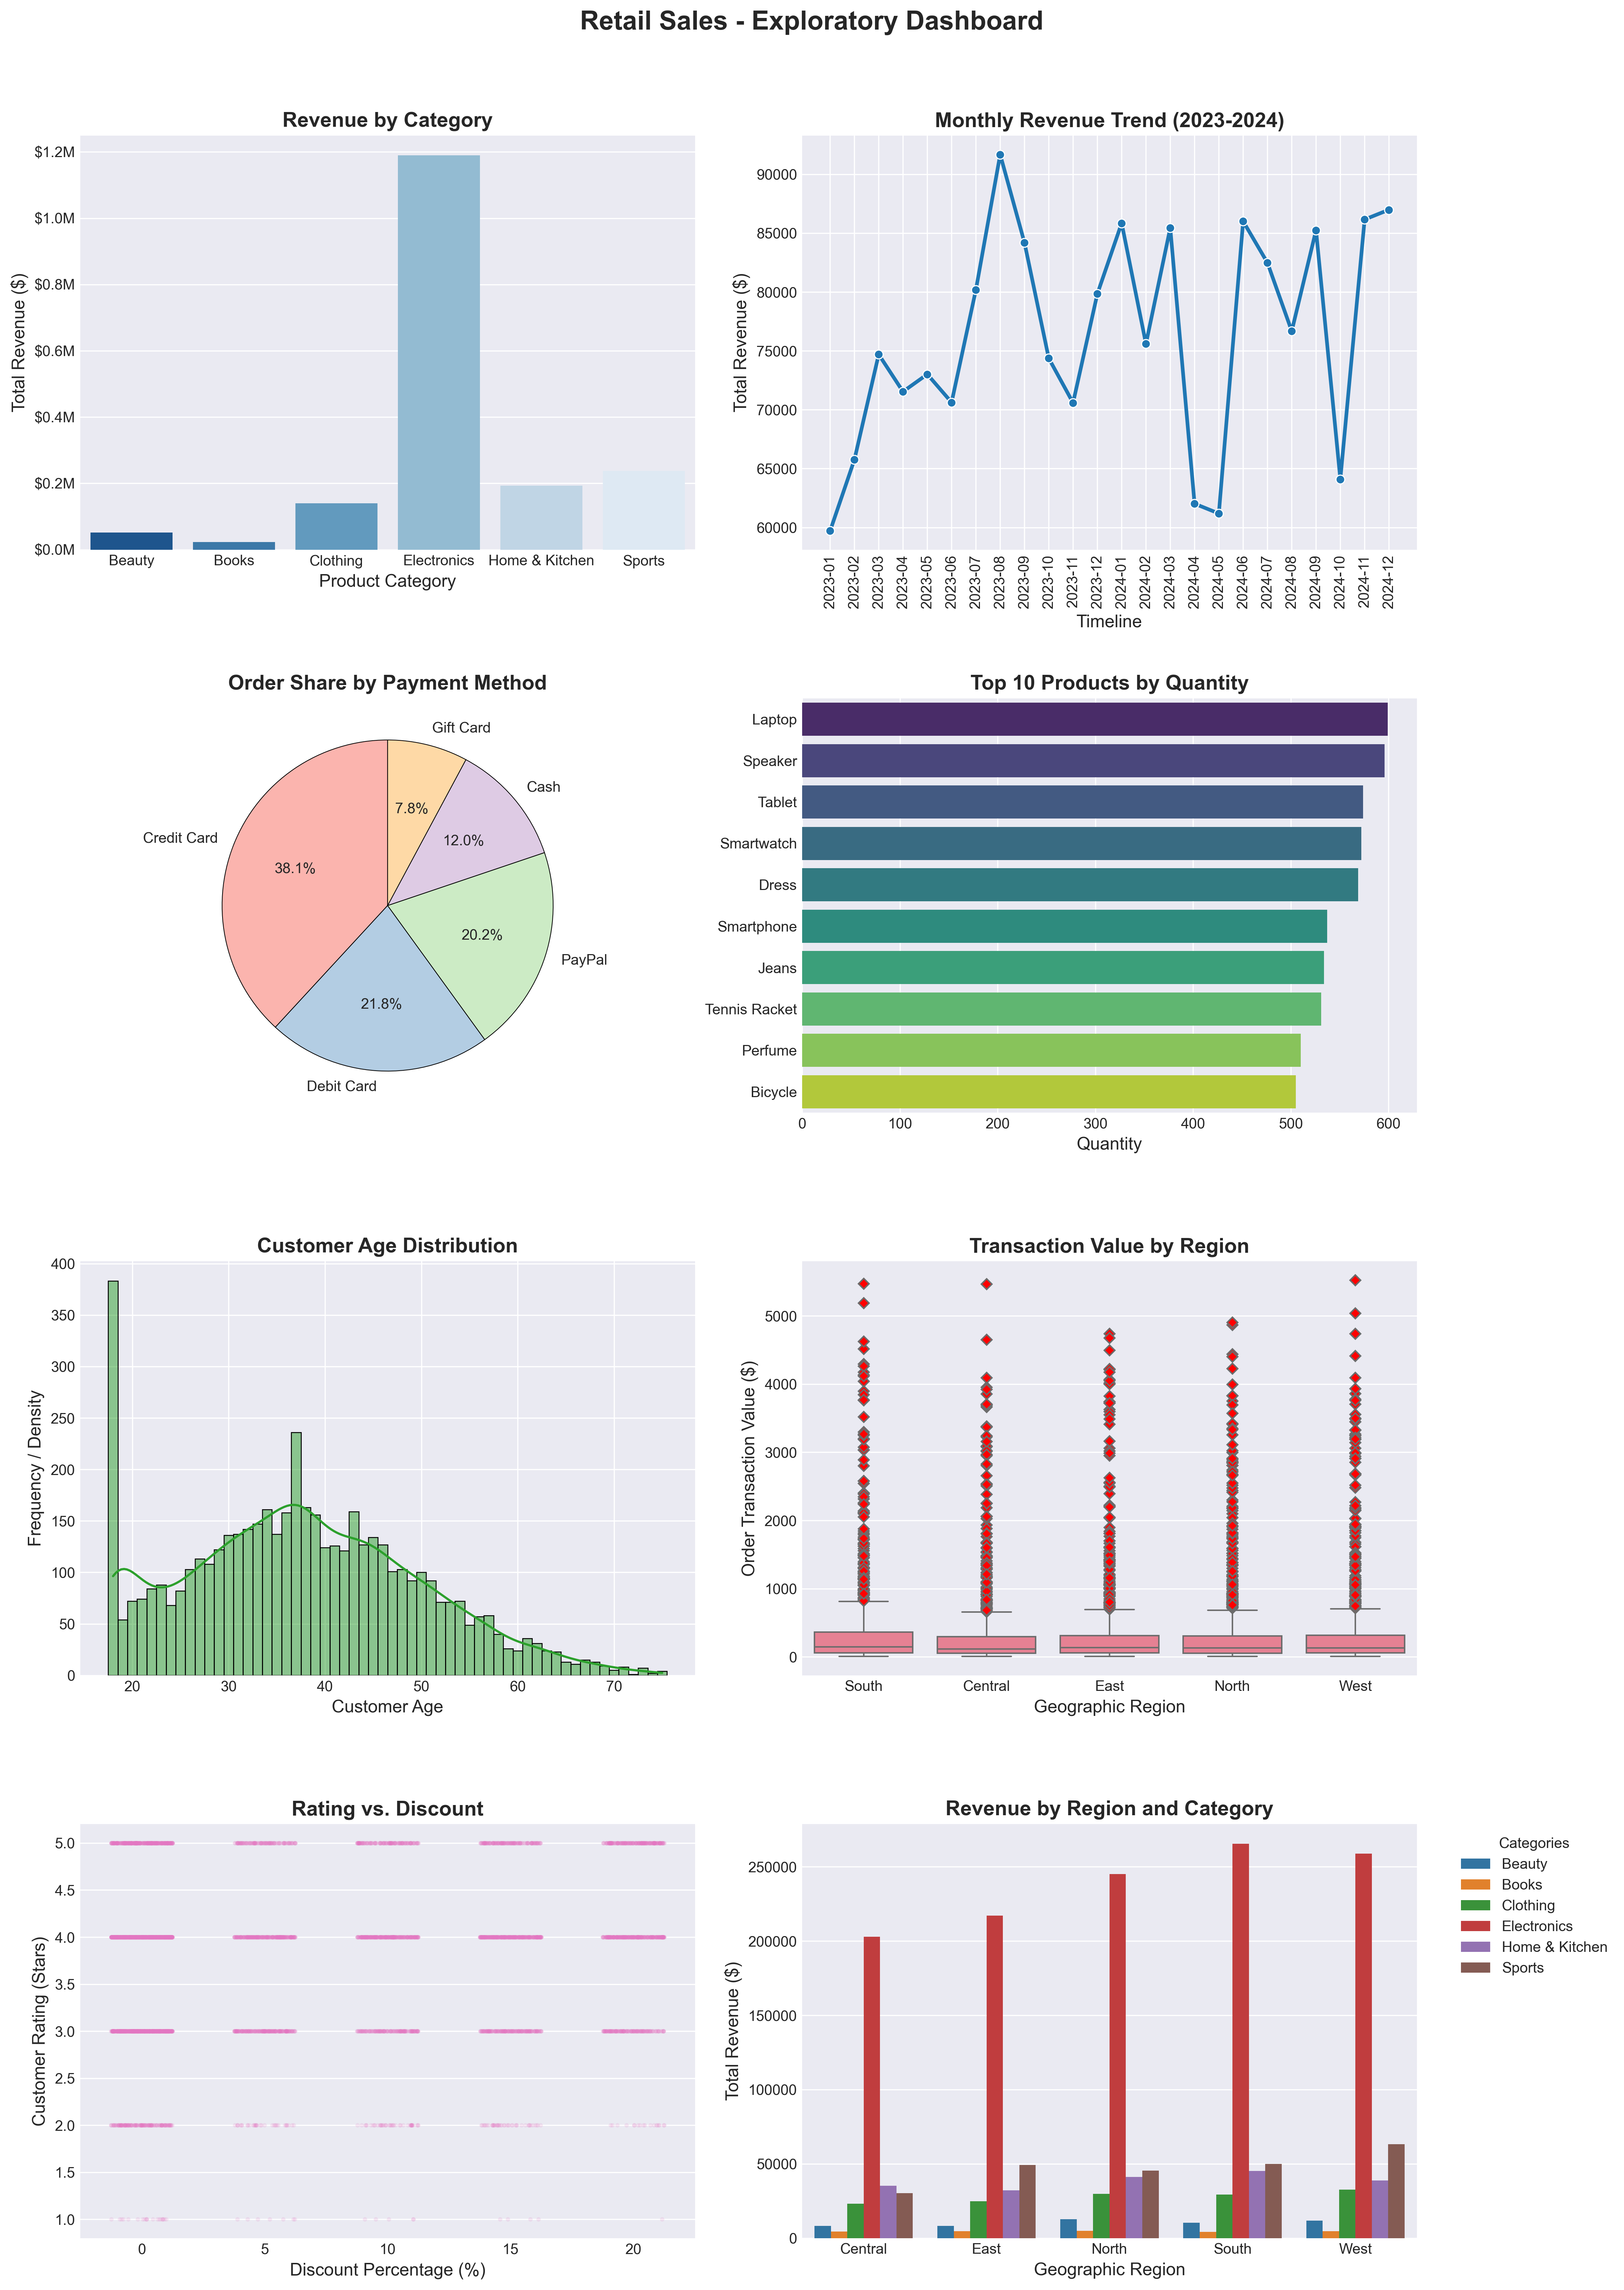

In [18]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (16, 22), dpi = 300)

plot_revenue_by_category(df, ax[0][0])
plot_monthly_revenue_trend(df, ax[0][1])
plot_payment_method_share(df, ax[1][0])
plot_top_products_by_quantity(df, ax[1][1])
plot_customer_age_distribution(df, ax[2][0])
plot_transaction_value_by_region(df, ax[2][1])
plot_rating_vs_discount(df, ax[3][0])
plot_revenue_by_region_and_category(df, ax[3][1])

fig.suptitle('Retail Sales - Exploratory Dashboard', fontsize = 18, fontweight = 'bold', y = 0.995)
plt.tight_layout(pad = 3.0, h_pad = 3.0, w_pad = 2.0)
plt.savefig('../reports/figures/eda_dashboard.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Retail Sales Analysis - Phase 4: Bonus Challenges

With the core analysis complete and the dashboard built, we now tackle **bonus challenges** 
that extend the project's depth. These tasks demonstrate advanced aggregation techniques, 
time-series smoothing, modular code design, and dataset export for future use.

**Tasks in this phase:**

1. **Customer Value Table** — aggregate total spend and order count per customer, then 
   rank the top 10 customers by revenue contribution.
2. **Rolling Average Overlay** — add a 7-day and 30-day moving average line on top of 
   the monthly revenue trend chart to smooth short-term volatility.
3. **Consolidated Dashboard** — already completed in Phase 3 (4×2 subplot grid).
4. **Export Cleaned Dataset** — already completed; `retail_sales_clean.csv` saved 
   during Phase 1.

--- 

## Customer Value Table

**Objective:** Identify high-value customers by aggregating their transaction history.

For each unique `customer_id`, we compute:
- **Total Spend** — sum of all `total_price` values across their orders
- **Order Count** — number of distinct orders they placed

The result is sorted by total spend (descending) to surface the **top 10 customers** — 
the most valuable segment for retention, loyalty programs, or targeted marketing.

This table answers: *Who are our most profitable customers?*

In [19]:
customer_value_table = df.groupby('customer_id', as_index = False).agg(total_spend = ('total_price', 'sum'),
                        order_count = ('order_id', 'count')).sort_values('total_spend', ascending = False).reset_index(drop = True)

print("Top 10 Customers by Total Spend:")
display(customer_value_table.head(10))

Top 10 Customers by Total Spend:


,customer_id,total_spend,order_count
0,10718,9664.36,3
1,10529,9216.87,5
2,10383,8983.34,5
3,11197,8602.46,8
4,10787,8423.60,9
5,10733,7590.60,7
6,10948,7543.58,5
7,10103,7436.51,8
8,10944,7427.68,7
9,10246,7188.63,4


## Monthly Revenue with Rolling Average

**Objective:** Overlay a smoothed trend line on the monthly revenue chart to identify underlying patterns obscured by month-to-month volatility.

We compute a **30-day rolling average** on the daily revenue data and display it on a secondary y-axis using `twinx()`, allowing both series to share a common time axis while respecting their vastly different scales.

The rolling average reveals:
- **Seasonal trends** — sustained upward or downward movements across quarters
- **Outliers** — months whose revenue deviates significantly from the smoothed trajectory

This visualization answers: *Beyond the noise, what is the true direction of our revenue?*

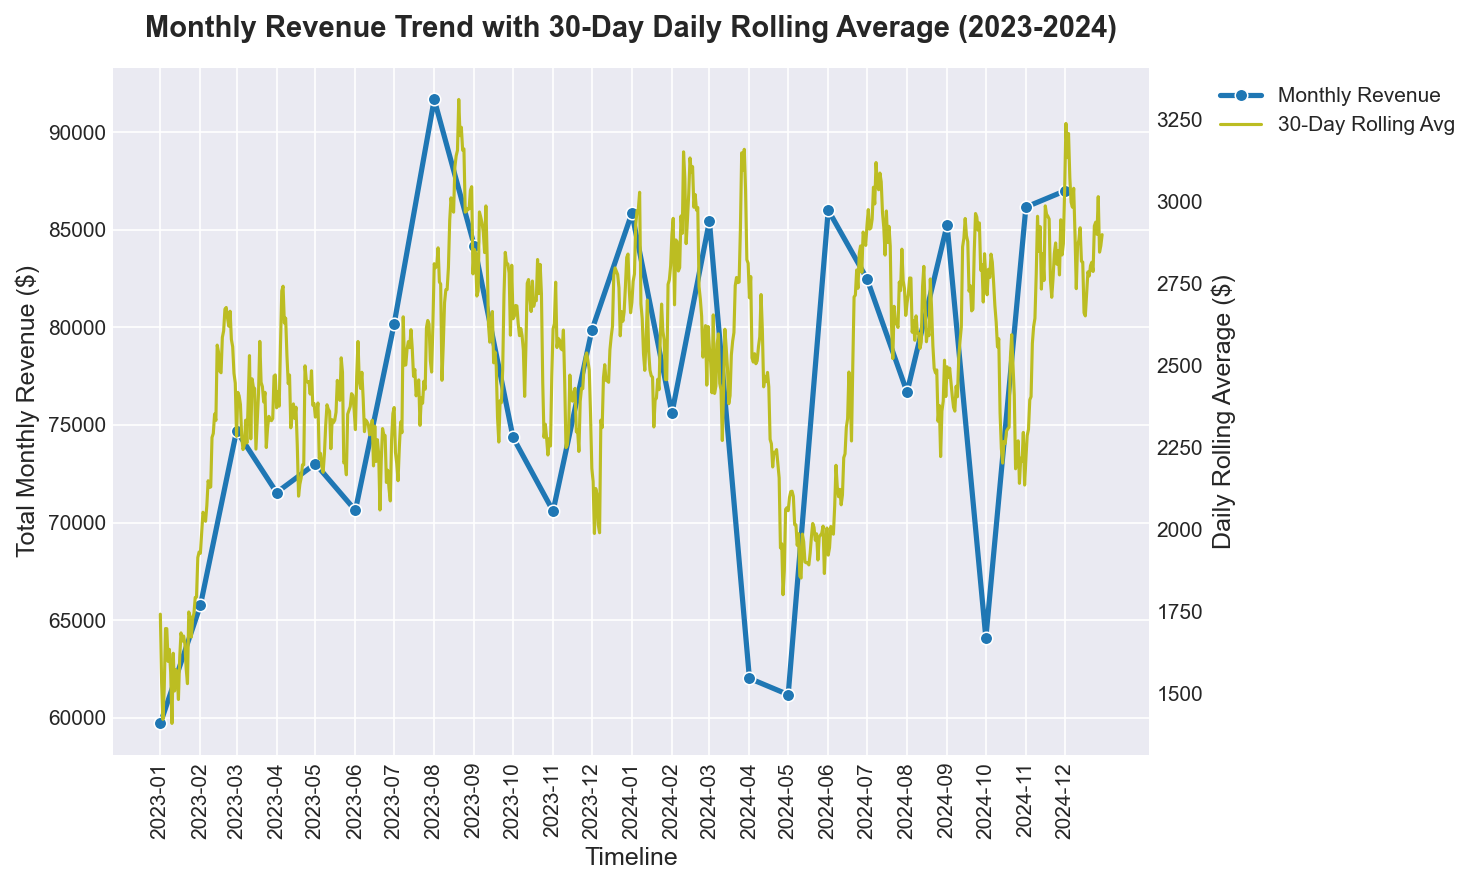

In [20]:
import matplotlib.dates as mdates

fig, monthly_ax = plt.subplots(figsize = (10, 6), dpi = 150)

df['order_Y-M'] = df['order_date'].dt.to_period('M').dt.to_timestamp()
monthly_revenue = df.groupby('order_Y-M', as_index = False).agg(total_revenue = ('total_price', 'sum'))
sns.lineplot(data = monthly_revenue, x = 'order_Y-M', y = 'total_revenue', ax = monthly_ax,
             zorder = 3, color = "#1f77b4", marker = "o", linewidth = 2.5, label = "Monthly Revenue")

rolling_ax = monthly_ax.twinx()
rolling_ax.grid(False)

daily_revenue = df.groupby('order_date', as_index = False).agg(total_revenue = ('total_price', 'sum'))
daily_revenue['rolling_30d'] = daily_revenue['total_revenue'].rolling(window = 30, min_periods = 1).mean()
sns.lineplot(data = daily_revenue, x = 'order_date', y = 'rolling_30d', ax = rolling_ax, 
             zorder = 2, color = '#bcbd22', label = '30-Day Rolling Avg')

monthly_ax.set_xlabel('Timeline', fontsize = 12)
monthly_ax.tick_params(axis = 'x', rotation = 90)
monthly_ax.set_ylabel('Total Monthly Revenue ($)', fontsize = 12)
monthly_ax.set_title("Monthly Revenue Trend with 30-Day Daily Rolling Average (2023-2024)",
                      fontsize = 14, fontweight = 'bold', pad = 15)
monthly_ax.set_xticks(monthly_revenue['order_Y-M'])
monthly_ax.margins(x = 0.05)
monthly_ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

rolling_ax.set_ylabel('Daily Rolling Average ($)', fontsize = 12)

handles_1, labels_1 = monthly_ax.get_legend_handles_labels()
handles_2, labels_2 = rolling_ax.get_legend_handles_labels()

if monthly_ax.get_legend() is not None:
    monthly_ax.get_legend().remove()
if rolling_ax.get_legend() is not None:
    rolling_ax.get_legend().remove()

monthly_ax.legend(handles_1 + handles_2, labels_1 + labels_2, loc = 'upper left', 
                  bbox_to_anchor = (1.05, 1))

plt.tight_layout()
plt.show()